In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import metrics
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import joblib

In [2]:
loan = pd.read_csv('loan.csv').drop(columns=['Loan_ID'])
loan.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
loan.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [4]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


In [5]:
# Categorical features → fill with mode
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History']:
    loan[col].fillna(loan[col].mode()[0], inplace=True)

# Numeric features → fill with median
for col in ['LoanAmount']:
    loan[col].fillna(loan[col].median(), inplace=True)

# Drop rows if target is missing
loan.dropna(subset=['Loan_Status'], inplace=True)

print("Remaining missing values:\n", loan.isnull().sum())

Remaining missing values:
 Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


/tmp/ipykernel_20932/3850014879.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan[col].fillna(loan[col].mode()[0], inplace=True)
/tmp/ipykernel_20932/3850014879.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

In [6]:
label_encoder = LabelEncoder()

# convert categorical columns to numerical
obj = (loan.dtypes == 'object')
print("categorial columns:", len(list(obj[obj].index)))

categorial columns: 7


In [7]:
for col in list(obj[obj].index):
    loan[col] = label_encoder.fit_transform(loan[col])
print(loan.head())
print(loan.info())

   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           0          0              0             5849   
1       1        1           1          0              0             4583   
2       1        1           0          0              1             3000   
3       1        1           0          1              0             2583   
4       1        0           0          0              0             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0             1.0   
1             1508.0       128.0             360.0             1.0   
2                0.0        66.0             360.0             1.0   
3             2358.0       120.0             360.0             1.0   
4                0.0       141.0             360.0             1.0   

   Property_Area  Loan_Status  
0              2            1  
1              0            0  
2              2    

In [8]:
obj = (loan.dtypes == 'object')
print(f"obj = {obj}")

obj = Gender               False
Married              False
Dependents           False
Education            False
Self_Employed        False
ApplicantIncome      False
CoapplicantIncome    False
LoanAmount           False
Loan_Amount_Term     False
Credit_History       False
Property_Area        False
Loan_Status          False
dtype: bool


<Axes: >

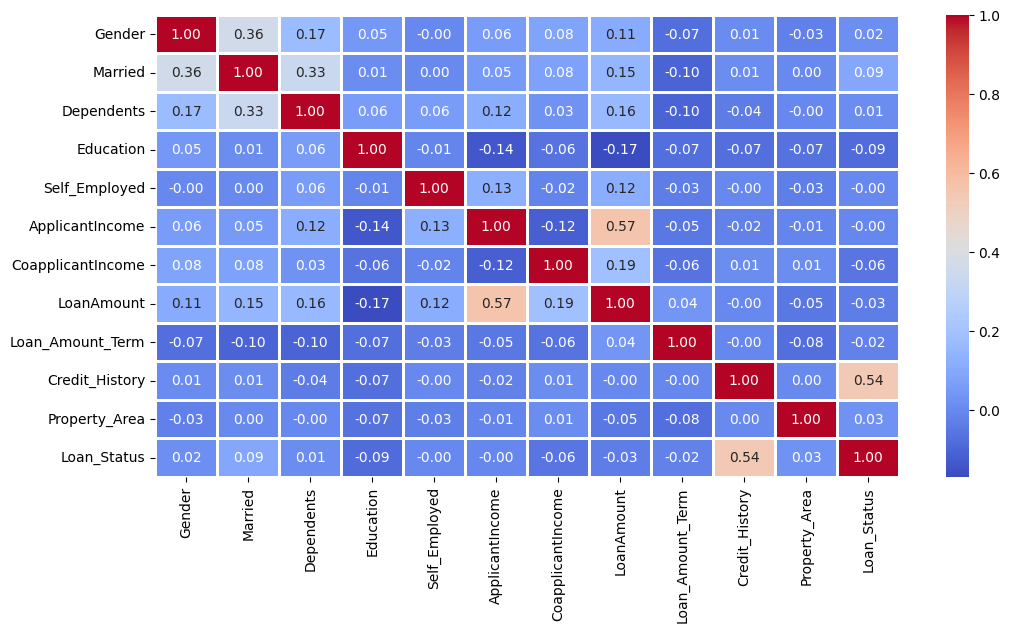

In [9]:
plt.figure(figsize=(12,6))
sns.heatmap(loan.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=2)

In [10]:
X = loan.drop('Loan_Status', axis=1)
y = loan['Loan_Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
print(X_train.shape, X_test.shape)

(368, 11) (246, 11)


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 转换回DataFrame以保留特征名称
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [12]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Support Vector Machine': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier()
}

results = {}
for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train_scaled_df, y_train)
    y_pred = model.predict(X_test_scaled_df)
    accuracy = metrics.accuracy_score(y_test, y_pred)
    results[model_name] = accuracy
    print(f"{model_name} Accuracy: {accuracy:.4f}")

Training Logistic Regression...
Logistic Regression Accuracy: 0.7927
Training Support Vector Machine...
Support Vector Machine Accuracy: 0.7967
Training K-Nearest Neighbors...
K-Nearest Neighbors Accuracy: 0.7642
Training Random Forest...
Random Forest Accuracy: 0.7886


In [13]:
sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)
print("\nModel Performance Ranking:")
for rank, (model_name, accuracy) in enumerate(sorted_results, start=1):
    print(f"{rank}. {model_name}: {accuracy:.4f}")


Model Performance Ranking:
1. Support Vector Machine: 0.7967
2. Logistic Regression: 0.7927
3. Random Forest: 0.7886
4. K-Nearest Neighbors: 0.7642


In [14]:
# 1. Initialize the SVM model
# Note: For large datasets, you might use SVC(max_iter=...) or a different solver
svm = SVC(random_state=42) 

# 2. Define the parameter grid
param_grid_svm = {
    # C is usually tested on a logarithmic scale
    'C': [0.1, 1, 10, 100], 
    
    # Common kernel types
    'kernel': ['linear', 'rbf'], 
    
    # Gamma is only relevant for 'rbf' and 'poly' kernels, 
    # but we include it in the grid, and GridSearchCV handles the combination.
    # 'auto' means 1/n_features, 'scale' means 1/(n_features * X.var())
    'gamma': ['scale', 'auto', 0.01, 0.1, 1] 
}

# 3. Initialize Grid Search
# cv=5: 5-fold cross-validation
# n_jobs=-1: Use all available processors
grid_search = GridSearchCV(
    estimator=svm, 
    param_grid=param_grid_svm, 
    cv=5, 
    n_jobs=-1, 
    scoring='accuracy',
    verbose=2 # Optional: prints progress updates
)

# 4. Fit the Grid Search to the training data (use scaled data if possible)
# Assuming you have X_train and y_train
grid_search.fit(X_train_scaled_df, y_train)

# 5. Print the results
print(f"Best Hyperparameters for SVM: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy for SVM: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Hyperparameters for SVM: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-Validation Accuracy for SVM: 0.8180


In [15]:
joblib.dump(grid_search.best_estimator_, 'loan_model.pkl')
joblib.dump(scaler, 'loan_scaler.pkl')
print("Model and scaler saved successfully.")

Model and scaler saved successfully.


In [20]:
test_data_list = [{
    'Gender': [0],  # Need to map this properly
    'Married': [0],
    'Dependents': [0],
    'Education': [0],
    'Self_Employed': [1],
    'ApplicantIncome': [0],
    'CoapplicantIncome': [0.0],
    'LoanAmount': [666.0],
    'Loan_Amount_Term': [360.0],
    'Credit_History': [0.0],
    'Property_Area': [0]
},
{
    'Gender': [1],  # Likely 'Male' based on encoding
    'Married': [1], # 'Yes'
    'Dependents': [0], # '0'
    'Education': [0], # 'Graduate'
    'Self_Employed': [0], # 'No'
    'ApplicantIncome': [700], # High income
    'CoapplicantIncome': [2000.0], # Additional income
    'LoanAmount': [120.0], # Reasonable loan amount
    'Loan_Amount_Term': [360.0], # Standard term
    'Credit_History': [1.0], # Good credit (most critical factor)
    'Property_Area': [2] # Likely 'Urban'
}]
model_loaded = joblib.load('loan_model.pkl')
scaler_loaded = joblib.load('loan_scaler.pkl')


In [ ]:
for test_data in test_data_list:
    test_df = pd.DataFrame(test_data)
    test_df_scaled = scaler_loaded.transform(test_df)
    # 缩放后转换回带列名的DataFrame
    test_df_scaled_with_names = pd.DataFrame(test_df_scaled, columns=test_df.columns)
    prediction = model_loaded.predict(test_df_scaled_with_names)
    print(f"Predicted Loan Status: {prediction[0]}")

Predicted Loan Status: 0
Predicted Loan Status: 1
